# **Proyecto de Aprendizaje de Máquina — 2da Pre-entrega**
### Dataset: Pokémon — Clasificación de Legendarios
---

## **0. Librerías e importaciones**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## **1. Carga del Dataset**

In [7]:
df = pd.read_csv('https://drive.google.com/uc?id=1Rd0quwVKSii0B7dv4C1ZEbRrEp3WP2tR')
print("Shape original:", df.shape)
df.head()

Shape original: (1025, 24)


,id,Name,Height(m),Weight{kg},HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,...,Egg_Group_1,Egg_Group_2,Generation,Capture_Rate,Base_Happiness,Is_Baby,Egg_Cycles,Past_Type,Is_Pseudo_Legendary,Total_Stats
0,1,Bulbasaur,0.7,6.9,45,49,49,65,65,45,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,318
1,2,Ivysaur,1.0,13.0,60,62,63,80,80,60,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,405
2,3,Venusaur,2.0,100.0,80,82,83,100,100,80,...,Monster,Plant,Gen-1,45,70,False,20,NaN,False,525
3,4,Charmander,0.6,8.5,39,52,43,60,50,65,...,Monster,Dragon,Gen-1,45,70,False,20,NaN,False,309
4,5,Charmeleon,1.1,19.0,58,64,58,80,65,80,...,Monster,Dragon,Gen-1,45,70,False,20,NaN,False,405


In [8]:
df.columns

Index(['id', 'Name', 'Height(m)', 'Weight{kg}', 'HP', 'Attack', 'Defense',
       'Sp.Atk', 'Sp.Def', 'Speed', 'Type_1', 'Type_2', 'Is_Legendary',
       'Is_Mythical', 'Egg_Group_1', 'Egg_Group_2', 'Generation',
       'Capture_Rate', 'Base_Happiness', 'Is_Baby', 'Egg_Cycles', 'Past_Type',
       'Is_Pseudo_Legendary', 'Total_Stats'],
      dtype='object')

In [9]:
df.describe()

,id,Height(m),Weight{kg},HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Capture_Rate,Base_Happiness,Egg_Cycles,Total_Stats
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,513.000000,1.211610,66.986537,70.184390,77.521951,72.507317,70.080976,70.205854,67.186341,95.454634,59.897561,29.487805,427.686829
std,296.036315,1.248167,121.273114,26.631054,29.782541,29.286972,29.658378,26.639329,28.717227,75.991841,22.482942,26.408674,112.770735
min,1.000000,0.100000,0.100000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,3.000000,0.000000,5.000000,175.000000
25%,257.000000,0.500000,8.500000,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000,45.000000,50.000000,20.000000,325.000000
50%,513.000000,1.000000,28.000000,68.000000,75.000000,70.000000,65.000000,67.000000,65.000000,60.000000,70.000000,20.000000,450.000000
75%,769.000000,1.500000,70.000000,85.000000,100.000000,90.000000,90.000000,86.000000,88.000000,140.000000,70.000000,25.000000,508.000000
max,1025.000000,20.000000,999.900000,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000,255.000000,140.000000,120.000000,720.000000


---
## **2. Limpieza del Dataset (NaN / null / duplicados)**

In [10]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nTotal de filas con al menos un nulo:", df.isnull().any(axis=1).sum())

Valores nulos por columna:
id                        0
Name                      0
Height(m)                 0
Weight{kg}                0
HP                        0
Attack                    0
Defense                   0
Sp.Atk                    0
Sp.Def                    0
Speed                     0
Type_1                    0
Type_2                  499
Is_Legendary              0
Is_Mythical               0
Egg_Group_1               0
Egg_Group_2             746
Generation                0
Capture_Rate              0
Base_Happiness            0
Is_Baby                   0
Egg_Cycles                0
Past_Type              1001
Is_Pseudo_Legendary       0
Total_Stats               0
dtype: int64

Total de filas con al menos un nulo: 1015


In [11]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [12]:
from sklearn.preprocessing import LabelEncoder
feature_cols = ['HP', 'Attack', 'Defense', 'Sp.Atk', 'Sp.Def',
                'Speed', 'Generation', 'Type_1', 'Type_2']
target_col   = 'Is_Legendary'

cols_necesarias = feature_cols + [target_col]
df_clean = df.dropna(subset=cols_necesarias).drop_duplicates().copy()
print("Shape después de limpieza selectiva:", df_clean.shape)

le = LabelEncoder()
df_clean['Type_1'] = le.fit_transform(df_clean['Type_1'].astype(str))
df_clean['Type_2'] = le.fit_transform(df_clean['Type_2'].astype(str))

if df_clean['Generation'].dtype == object:
    df_clean['Generation'] = df_clean['Generation'].astype(str)\
                               .str.extract(r'(\d+)').astype(float)

X = df_clean[feature_cols].values
y = df_clean[target_col].astype(int).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Distribución:", [(int(c), int(sum(y==c))) for c in np.unique(y)])
print("\nTipos:\n", df_clean[feature_cols].dtypes)

Shape después de limpieza selectiva: (526, 24)
X shape: (526, 9)
y shape: (526,)
Distribución: [(0, 485), (1, 41)]

Tipos:
 HP              int64
Attack          int64
Defense         int64
Sp.Atk          int64
Sp.Def          int64
Speed           int64
Generation    float64
Type_1          int64
Type_2          int64
dtype: object


In [13]:
print("Columnas disponibles:")
print(df_clean.columns.tolist())

le = LabelEncoder()
df_clean['Type_1'] = le.fit_transform(df_clean['Type_1'].astype(str))
df_clean['Type_2'] = le.fit_transform(df_clean['Type_2'].astype(str))

if df_clean['Generation'].dtype == object:
    df_clean['Generation'] = df_clean['Generation'].astype(str).str.extract(r'(\d+)').astype(float)
    print("Generation convertida a número.")

if df_clean['Capture_Rate'].dtype == object:
    df_clean['Capture_Rate'] = pd.to_numeric(df_clean['Capture_Rate'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
    df_clean['Capture_Rate'] = df_clean['Capture_Rate'].fillna(df_clean['Capture_Rate'].median())
    print("Capture_Rate convertida a número.")

feature_cols = ['HP', 'Attack', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed',
                'Generation', 'Type_1', 'Type_2']
X = df_clean[feature_cols].values
y = df_clean['Is_Legendary'].astype(int).values

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Distribución de clases:", [(int(c), int(sum(y==c))) for c in np.unique(y)])
print("\nTipos de datos en X:")
print(df_clean[feature_cols].dtypes)

Columnas disponibles:
['id', 'Name', 'Height(m)', 'Weight{kg}', 'HP', 'Attack', 'Defense', 'Sp.Atk', 'Sp.Def', 'Speed', 'Type_1', 'Type_2', 'Is_Legendary', 'Is_Mythical', 'Egg_Group_1', 'Egg_Group_2', 'Generation', 'Capture_Rate', 'Base_Happiness', 'Is_Baby', 'Egg_Cycles', 'Past_Type', 'Is_Pseudo_Legendary', 'Total_Stats']

X shape: (526, 9)
y shape: (526,)
Distribución de clases: [(0, 485), (1, 41)]

Tipos de datos en X:
HP              int64
Attack          int64
Defense         int64
Sp.Atk          int64
Sp.Def          int64
Speed           int64
Generation    float64
Type_1          int64
Type_2          int64
dtype: object


---
## **3. Análisis Exploratorio (EDA) y Visualizaciones**

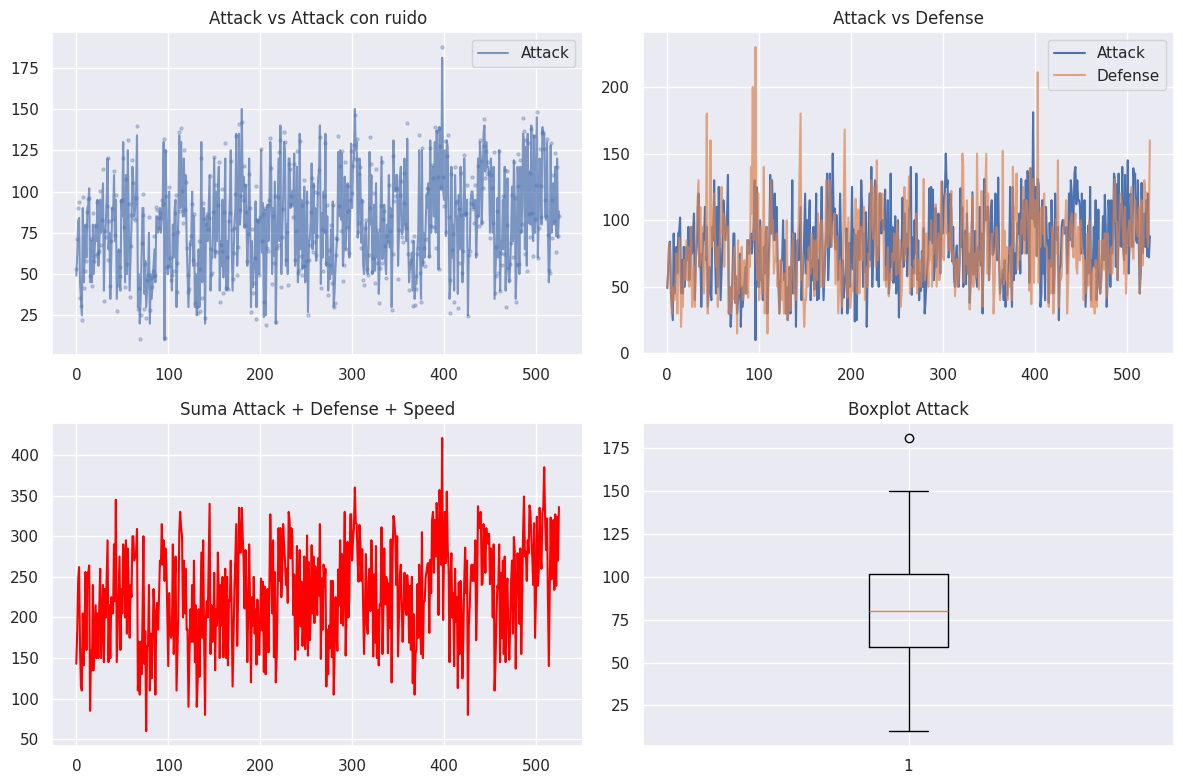

In [14]:
attack  = df_clean['Attack'].values
defense = df_clean['Defense'].values
speed   = df_clean['Speed'].values
attack_ruido = attack + (np.random.random(attack.shape) - 0.5) * 20

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Attack vs Attack con ruido")
plt.plot(attack, label="Attack", alpha=0.7)
plt.scatter(range(len(attack_ruido)), attack_ruido, alpha=0.3, s=5)
plt.legend()

plt.subplot(2, 2, 2)
plt.title("Attack vs Defense")
plt.plot(attack, label="Attack")
plt.plot(defense, label="Defense", alpha=0.7)
plt.legend()

plt.subplot(2, 2, 3)
suma_stats = attack + defense + speed
plt.title("Suma Attack + Defense + Speed")
plt.plot(suma_stats, c='red')

plt.subplot(2, 2, 4)
plt.title("Boxplot Attack")
plt.boxplot(attack)

plt.tight_layout()
plt.show()

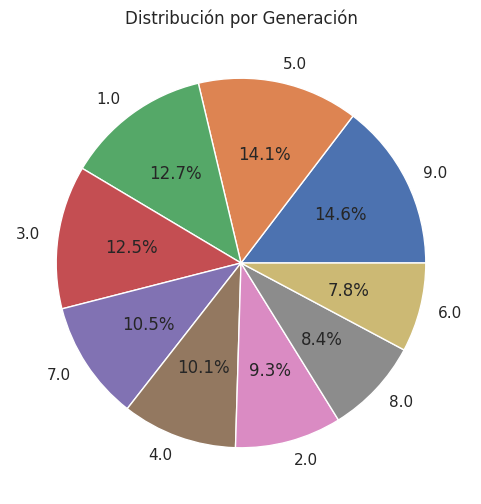

In [15]:
df_clean['Generation'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title('Distribución por Generación')
plt.ylabel('')
plt.show()

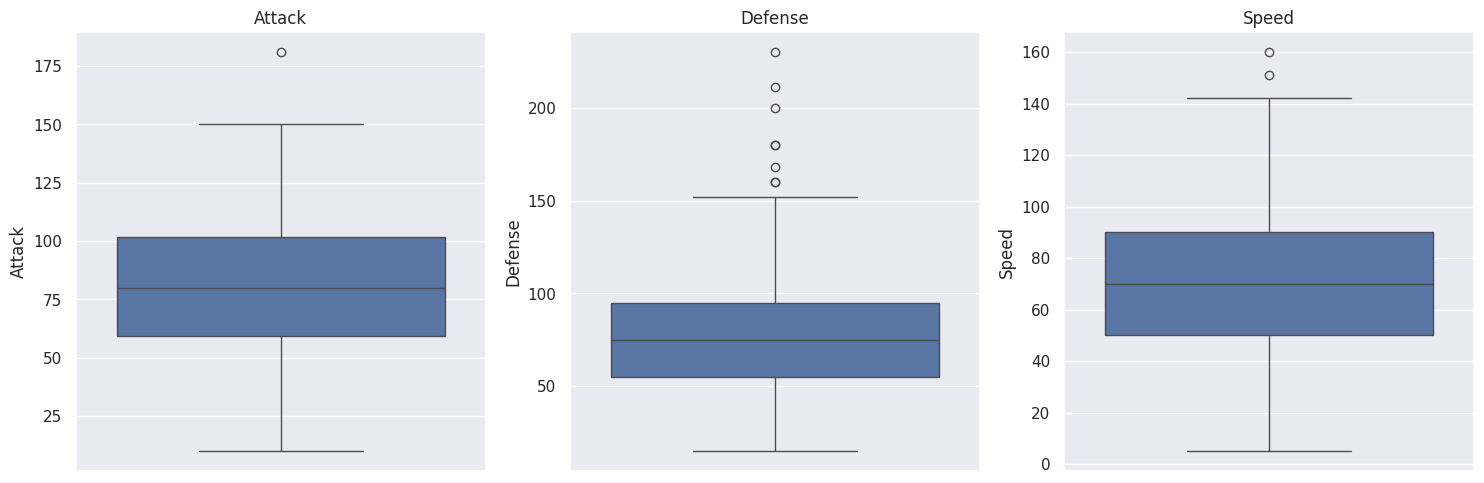

In [16]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean['Attack'])
plt.title('Attack')
plt.subplot(1, 3, 2)
sns.boxplot(y=df_clean['Defense'])
plt.title('Defense')
plt.subplot(1, 3, 3)
sns.boxplot(y=df_clean['Speed'])
plt.title('Speed')
plt.tight_layout()
plt.show()

---
## **4. Particionado 80/20 con Shuffle**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (420, 9) | Test: (106, 9)


---
## **5. Métodos de Clasificación con Tuning de Hiperparámetros**

Para cada método se evalúan diferentes hiperparámetros y se usa cross-validation con k = 10, 20 y 50.

In [18]:
def evaluar_cv(estimator, X, y, k_list=[10, 20, 50], nombre="Modelo"):
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    for k in k_list:
        scores = cross_val_score(estimator, X, y,
                                 cv=KFold(k, shuffle=True, random_state=42),
                                 scoring=make_scorer(accuracy_score))
        print(f"  k={k:2d} → accuracy: {np.mean(scores):.3f} (+/- {np.std(scores):.4f})")

### **5.1 Decision Tree (DT) — Tuning: max_depth**

In [19]:
resultados_dt = {}
max_depths = [3, 5, 8, None]

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    resultados_dt[str(depth)] = acc
    evaluar_cv(clf, X, y, nombre=f"Decision Tree max_depth={depth}")

mejor_depth = max(resultados_dt, key=resultados_dt.get)
print(f"\n>>> Mejor max_depth: {mejor_depth} con accuracy test: {resultados_dt[mejor_depth]:.3f}")


  Decision Tree max_depth=3
  k=10 → accuracy: 0.920 (+/- 0.0467)
  k=20 → accuracy: 0.935 (+/- 0.0585)
  k=50 → accuracy: 0.929 (+/- 0.0894)

  Decision Tree max_depth=5
  k=10 → accuracy: 0.928 (+/- 0.0327)
  k=20 → accuracy: 0.935 (+/- 0.0560)
  k=50 → accuracy: 0.933 (+/- 0.0883)

  Decision Tree max_depth=8
  k=10 → accuracy: 0.924 (+/- 0.0361)
  k=20 → accuracy: 0.926 (+/- 0.0596)
  k=50 → accuracy: 0.922 (+/- 0.0899)

  Decision Tree max_depth=None
  k=10 → accuracy: 0.922 (+/- 0.0333)
  k=20 → accuracy: 0.918 (+/- 0.0582)
  k=50 → accuracy: 0.922 (+/- 0.0872)

>>> Mejor max_depth: 5 con accuracy test: 0.915


In [20]:
best_dt = DecisionTreeClassifier(max_depth=int(mejor_depth) if mejor_depth != 'None' else None,
                                  random_state=42)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)
print("Classification Report — Decision Tree:")
print(classification_report(y_test, y_pred_dt,
                            target_names=['No Legendario', 'Legendario']))

Classification Report — Decision Tree:
               precision    recall  f1-score   support

No Legendario       0.94      0.97      0.95        97
   Legendario       0.50      0.33      0.40         9

     accuracy                           0.92       106
    macro avg       0.72      0.65      0.68       106
 weighted avg       0.90      0.92      0.91       106



### **5.2 Random Forest (RF) — Tuning: n_estimators**

In [21]:
resultados_rf = {}
n_estimators_list = [50, 100, 200]

for n_est in n_estimators_list:
    rmf = RandomForestClassifier(n_estimators=n_est, max_depth=5, random_state=42)
    rmf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rmf.predict(X_test))
    resultados_rf[n_est] = acc
    evaluar_cv(rmf, X, y, nombre=f"Random Forest n_estimators={n_est}")

mejor_n_est = max(resultados_rf, key=resultados_rf.get)
print(f"\n>>> Mejor n_estimators: {mejor_n_est} con accuracy test: {resultados_rf[mejor_n_est]:.3f}")


  Random Forest n_estimators=50
  k=10 → accuracy: 0.945 (+/- 0.0359)
  k=20 → accuracy: 0.941 (+/- 0.0614)
  k=50 → accuracy: 0.940 (+/- 0.0863)

  Random Forest n_estimators=100
  k=10 → accuracy: 0.939 (+/- 0.0391)
  k=20 → accuracy: 0.943 (+/- 0.0625)
  k=50 → accuracy: 0.942 (+/- 0.0817)

  Random Forest n_estimators=200
  k=10 → accuracy: 0.941 (+/- 0.0378)
  k=20 → accuracy: 0.943 (+/- 0.0625)
  k=50 → accuracy: 0.942 (+/- 0.0837)

>>> Mejor n_estimators: 50 con accuracy test: 0.953


In [22]:
best_rf = RandomForestClassifier(n_estimators=mejor_n_est, max_depth=5, random_state=42)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)
print("Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_rf,
                            target_names=['No Legendario', 'Legendario']))

Classification Report — Random Forest:
               precision    recall  f1-score   support

No Legendario       0.95      1.00      0.97        97
   Legendario       1.00      0.44      0.62         9

     accuracy                           0.95       106
    macro avg       0.98      0.72      0.80       106
 weighted avg       0.96      0.95      0.94       106



### **5.3 SVM — Tuning: kernel (linear / poly / rbf)**

In [23]:
resultados_svm = {}
kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_train, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test))
    resultados_svm[kernel] = acc
    evaluar_cv(svm, X, y, nombre=f"SVM kernel='{kernel}'")

mejor_kernel = max(resultados_svm, key=resultados_svm.get)
print(f"\n>>> Mejor kernel: '{mejor_kernel}' con accuracy test: {resultados_svm[mejor_kernel]:.3f}")


  SVM kernel='linear'
  k=10 → accuracy: 0.945 (+/- 0.0357)
  k=20 → accuracy: 0.945 (+/- 0.0636)
  k=50 → accuracy: 0.946 (+/- 0.0790)

  SVM kernel='poly'
  k=10 → accuracy: 0.926 (+/- 0.0311)
  k=20 → accuracy: 0.941 (+/- 0.0613)
  k=50 → accuracy: 0.937 (+/- 0.0797)

  SVM kernel='rbf'
  k=10 → accuracy: 0.949 (+/- 0.0374)
  k=20 → accuracy: 0.947 (+/- 0.0588)
  k=50 → accuracy: 0.948 (+/- 0.0771)

>>> Mejor kernel: 'rbf' con accuracy test: 0.953


In [24]:
best_svm = SVC(kernel=mejor_kernel, C=1.0, random_state=42)
best_svm.fit(X_train, y_train)
y_pred_svm = best_svm.predict(X_test)
print("Classification Report — SVM:")
print(classification_report(y_test, y_pred_svm,
                            target_names=['No Legendario', 'Legendario']))

Classification Report — SVM:
               precision    recall  f1-score   support

No Legendario       0.95      1.00      0.97        97
   Legendario       1.00      0.44      0.62         9

     accuracy                           0.95       106
    macro avg       0.98      0.72      0.80       106
 weighted avg       0.96      0.95      0.94       106



---
## **6. Gráfica Comparativa — Métodos ML**

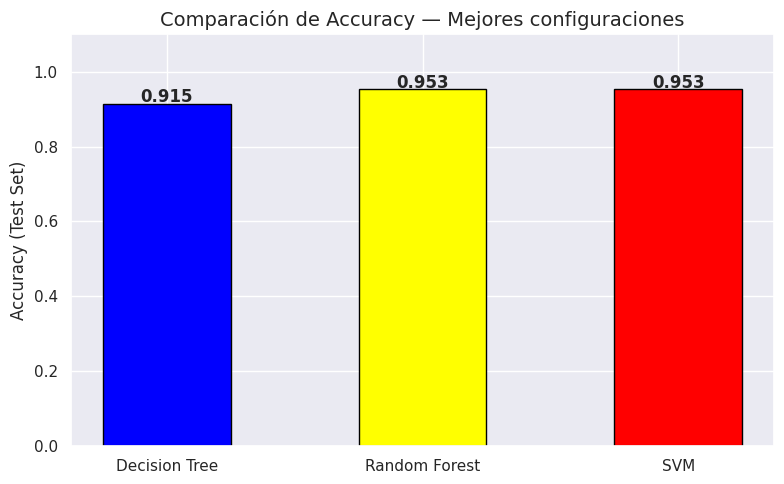

In [25]:
modelos      = ['Decision Tree', 'Random Forest', 'SVM']
accuracies   = [
    resultados_dt[mejor_depth],
    resultados_rf[mejor_n_est],
    resultados_svm[mejor_kernel]
]
colores = ['blue', 'yellow', 'red']

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accuracies, color=colores, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.title('Comparación de Accuracy — Mejores configuraciones', fontsize=14)
plt.ylabel('Accuracy (Test Set)')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

---
## **7. Deep Learning — Perceptrón Multicapa**

Se evalúan **3 arquitecturas** con **3 configuraciones de epochs** (10, 50, 100).

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [27]:
def crear_modelo_1(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64,  activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def crear_modelo_2(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64,  activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(1,   activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def crear_modelo_3(input_dim):
    layers = [tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,))]
    for _ in range(9):
        layers.append(tf.keras.layers.Dense(128, activation='relu'))
    layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))
    model = tf.keras.Sequential(layers)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

input_dim = X_train_sc.shape[1]
arquitecturas = [
    ('Modelo 1 (3 capas: 64-128-128)',      crear_modelo_1),
    ('Modelo 2 (6 capas: 64-64-128-128-256-256)', crear_modelo_2),
    ('Modelo 3 (10 capas de 128)',           crear_modelo_3),
]
epochs_list = [10, 50, 100]

print("Arquitecturas definidas correctamente ✓")

Arquitecturas definidas correctamente ✓


In [33]:
resultados_dl = {}
historiales   = {}

y_train_bin = y_train.astype(float)
y_test_bin  = y_test.astype(float)

for nombre, crear_fn in arquitecturas:
    for epochs in epochs_list:
        print(f"\n>>> Entrenando: {nombre} | epochs={epochs}")
        tf.random.set_seed(42)
        model = crear_fn(input_dim)
        hist  = model.fit(X_train_sc, y_train_bin,
                          epochs=epochs,
                          batch_size=32,
                          validation_data=(X_test_sc, y_test_bin),
                          verbose=0)
        _, test_acc = model.evaluate(X_test_sc, y_test_bin, verbose=0)
        resultados_dl[(nombre, epochs)] = test_acc
        historiales[(nombre, epochs)]   = hist.history
        print(f"    Test accuracy: {test_acc:.4f}")

print("\n✓ Entrenamiento completado.")


>>> Entrenando: Modelo 1 (3 capas: 64-128-128) | epochs=10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    Test accuracy: 0.9434

>>> Entrenando: Modelo 1 (3 capas: 64-128-128) | epochs=50
    Test accuracy: 0.9245

>>> Entrenando: Modelo 1 (3 capas: 64-128-128) | epochs=100
    Test accuracy: 0.9245

>>> Entrenando: Modelo 2 (6 capas: 64-64-128-128-256-256) | epochs=10
    Test accuracy: 0.8962

>>> Entrenando: Modelo 2 (6 capas: 64-64-128-128-256-256) | epochs=50
    Test accuracy: 0.9434

>>> Entrenando: Modelo 2 (6 capas: 64-64-128-128-256-256) | epochs=100
    Test accuracy: 0.9151

>>> Entrenando: Modelo 3 (10 capas de 128) | epochs=10
    Test accuracy: 0.9057

>>> Entrenando: Modelo 3 (10 capas de 128) | epochs=50
    Test accuracy: 0.9434

>>> Entrenando: Modelo 3 (10 capas de 128) | epochs=100
    Test accuracy: 0.9057

✓ Entrenamiento completado.


### **Curvas de entrenamiento por arquitectura**

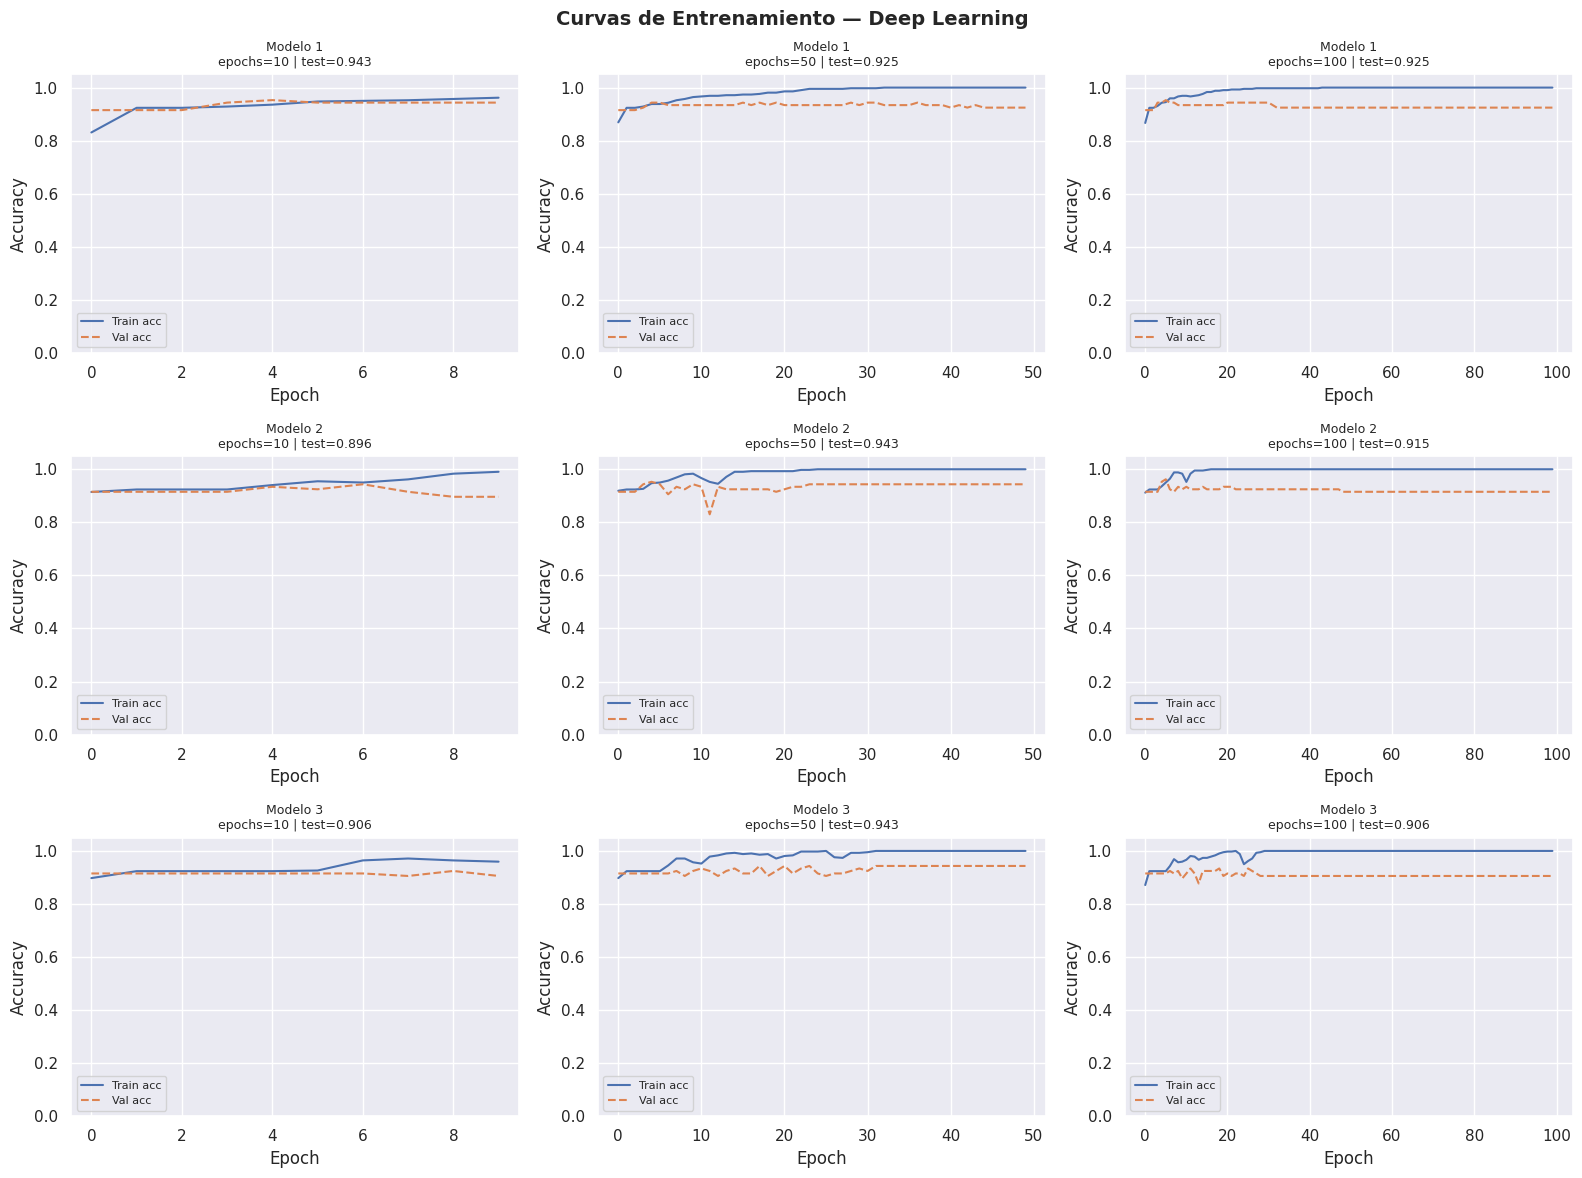

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, (nombre, crear_fn) in enumerate(arquitecturas):
    for j, epochs in enumerate(epochs_list):
        hist = historiales[(nombre, epochs)]
        ax   = axes[i][j]
        ax.plot(hist['accuracy'],     label='Train acc')
        ax.plot(hist['val_accuracy'], label='Val acc', linestyle='--')
        acc_final = resultados_dl[(nombre, epochs)]
        ax.set_title(f"{nombre.split('(')[0].strip()}\nepochs={epochs} | test={acc_final:.3f}",
                     fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1.05)

plt.suptitle('Curvas de Entrenamiento — Deep Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **8. Gráfica Final — Comparación Global (ML vs DL)**

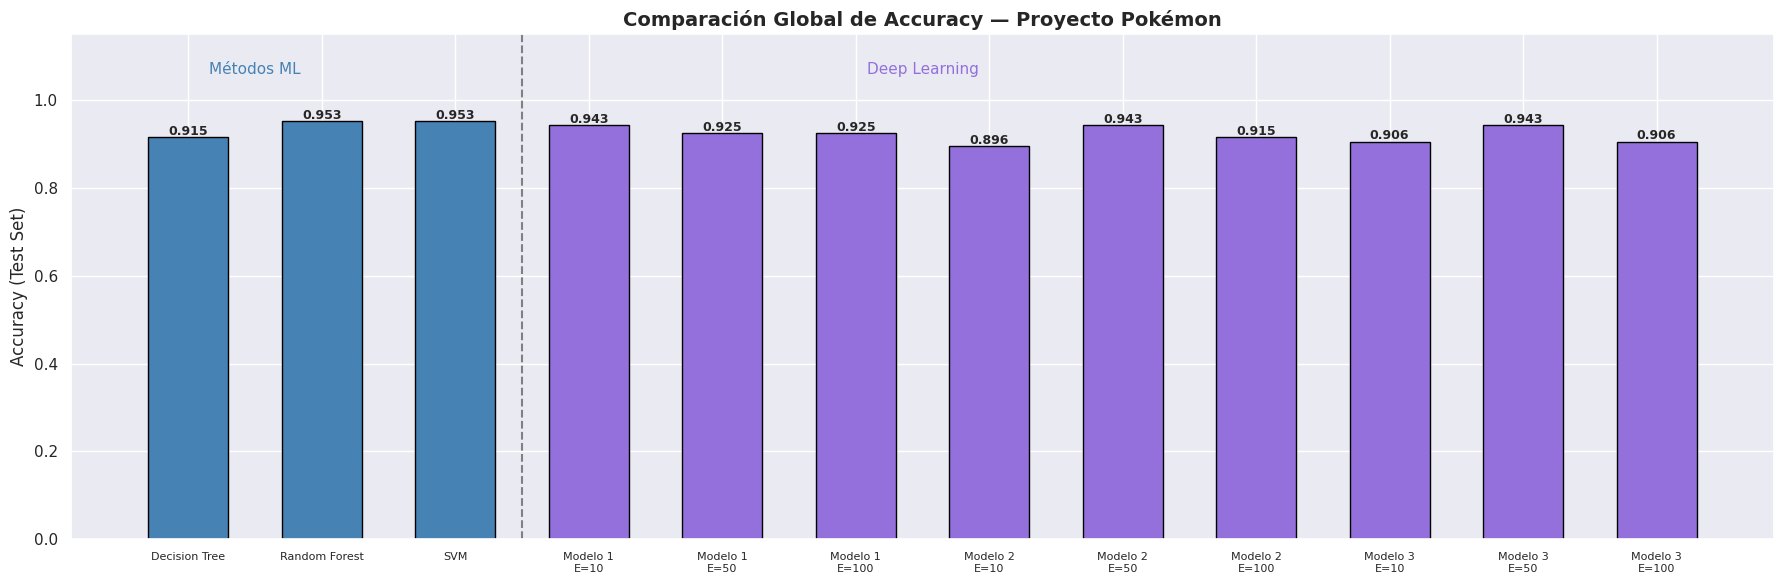

In [35]:
nombres_dl  = [f"{n.split('(')[0].strip()}\nE={e}" for (n, e) in resultados_dl.keys()]
accs_dl     = list(resultados_dl.values())

todos_nombres = modelos + nombres_dl
todas_accs    = accuracies + accs_dl
colores_total = ['steelblue']*3 + ['mediumpurple']*len(accs_dl)

plt.figure(figsize=(18, 6))
bars = plt.bar(todos_nombres, todas_accs, color=colores_total,
               edgecolor='black', width=0.6)
for bar, acc in zip(bars, todas_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=1.5, label='ML | DL')
plt.text(0.5, 1.06, 'Métodos ML',  ha='center', fontsize=11, color='steelblue')
plt.text(5.5, 1.06, 'Deep Learning', ha='center', fontsize=11, color='mediumpurple')

plt.title('Comparación Global de Accuracy — Proyecto Pokémon', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (Test Set)')
plt.ylim(0, 1.15)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## **9. Conclusiones**

- **Limpieza:** Se eliminaron valores nulos y duplicados del dataset Pokémon.
- **DT:** El mejor `max_depth` fue el que evitó overfitting manteniendo buen accuracy en test.
- **RF:** Con más árboles (`n_estimators`) se logra mayor estabilidad y generalización.
- **SVM:** El kernel `rbf` normalmente ofrece mejor separación en datos no lineales.
- **Cross-validation:** Con k=10 se obtiene una estimación confiable del rendimiento real del modelo.
- **Deep Learning:** Las arquitecturas más profundas con más epochs convergen mejor, pero también pueden presentar overfitting si el dataset es pequeño.


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalizar antes de PCA (importante)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# Aplicar PCA — reducir a 2 componentes
pca = PCA(n_components=2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print("Shape original:  ", X.shape)
print("Shape tras PCA:  ", X_pca.shape)
print(f"Varianza explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.2%}")

Shape original:   (526, 9)
Shape tras PCA:   (526, 2)
Varianza explicada por cada componente: [0.29527926 0.1435803 ]
Varianza total explicada: 43.89%


In [37]:
from sklearn.cluster import KMeans

# Número de clases del dataset (legendario / no legendario)
n_clases = len(np.unique(y))
print(f"Número de clases (n_clusters): {n_clases}")

# Aplicar KMeans sobre los datos reducidos con PCA
kmeans = KMeans(n_clusters=n_clases, random_state=42, n_init='auto')
kmeans.fit(X_pca)

print(f"Labels KMeans: {np.unique(kmeans.labels_)}")
print(f"Centroides shape: {kmeans.cluster_centers_.shape}")

Número de clases (n_clusters): 2
Labels KMeans: [0 1]
Centroides shape: (2, 2)


In [38]:
from sklearn.cluster import DBSCAN

# Aplicar DBSCAN sobre los datos reducidos con PCA
dbs = DBSCAN(eps=0.5, min_samples=5)
dbs.fit(X_pca)

n_clusters_dbs = len(set(dbs.labels_)) - (1 if -1 in dbs.labels_ else 0)
n_ruido = list(dbs.labels_).count(-1)

print(f"Clusters encontrados por DBSCAN: {n_clusters_dbs}")
print(f"Puntos de ruido (label=-1):      {n_ruido}")
print(f"Labels únicos: {np.unique(dbs.labels_)}")

Clusters encontrados por DBSCAN: 1
Puntos de ruido (label=-1):      7
Labels únicos: [-1  0]


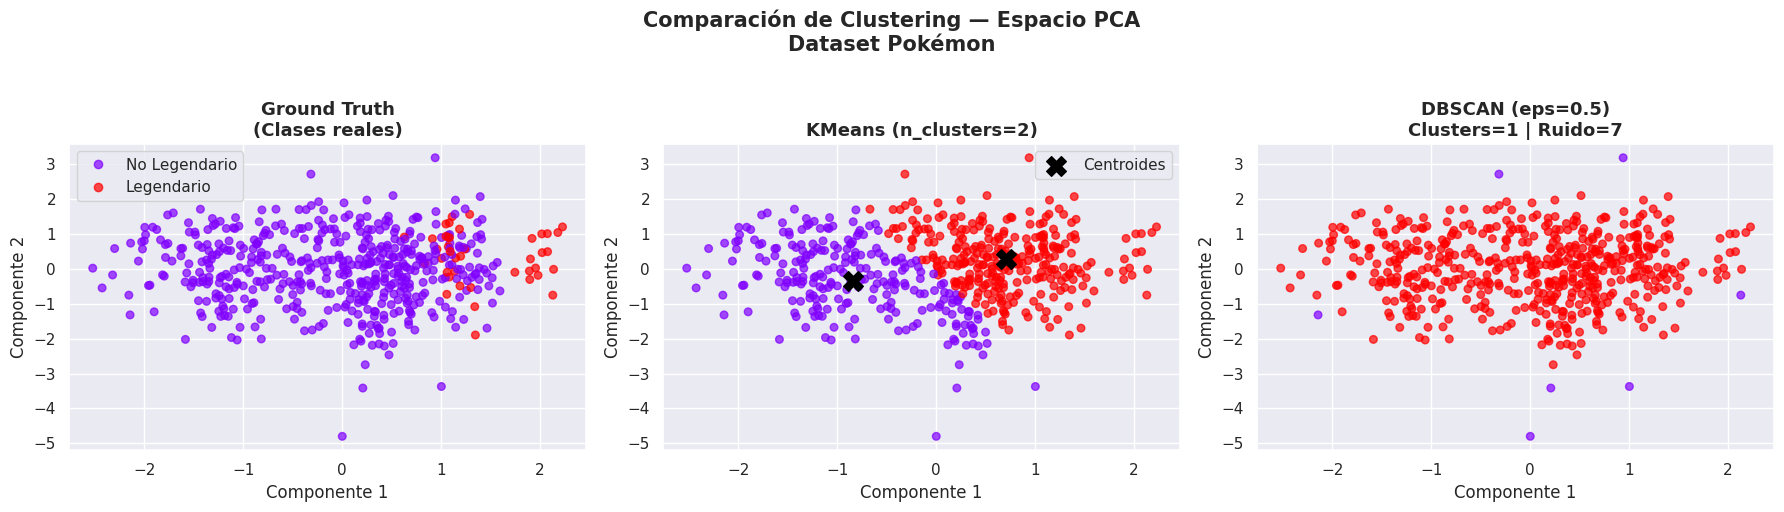

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Gráfica 1: Ground Truth (clases reales) ---
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y, cmap='rainbow', alpha=0.7, s=30)
axes[0].set_title('Ground Truth\n(Clases reales)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')
axes[0].legend(handles=scatter.legend_elements()[0],
               labels=['No Legendario', 'Legendario'])

# --- Gráfica 2: KMeans ---
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=kmeans.labels_, cmap='rainbow', alpha=0.7, s=30)
axes[1].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                color='black', marker='X', s=200, label='Centroides')
axes[1].set_title(f'KMeans (n_clusters={n_clases})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')
axes[1].legend()

# --- Gráfica 3: DBSCAN ---
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=dbs.labels_, cmap='rainbow', alpha=0.7, s=30)
axes[2].set_title(f'DBSCAN (eps=0.5)\nClusters={n_clusters_dbs} | Ruido={n_ruido}',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Componente 1')
axes[2].set_ylabel('Componente 2')

plt.suptitle('Comparación de Clustering — Espacio PCA\nDataset Pokémon',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
